<a href="https://colab.research.google.com/github/mohammadMotevali/ArtificialNeuralNetworks-ComputationalIntelligence-AUT/blob/main/RL_HandsOn_1_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In The Name of God

## Packages & Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging

logging.basicConfig(level=logging.INFO,
                    filename='rl_simulation.log',
                    filemode='w',
                    format='%(asctime)s - %(levelname)s - %(message)s')

## Environments

In [ ]:
class Environment:
    def __init__(self, k, reward_model, **kwargs):

        self.k = k
        self.reward_model = reward_model.lower()
        self.kwargs = kwargs
        self._set_arms()

    def _set_arms(self):

        if self.reward_model == 'normal':
            self.means = self.kwargs.get('means')
            self.stds = self.kwargs.get('stds')
            # if self.means is None or len(self.means) != self.k or self.stds is None or len(self.stds) != self.k:
            #      raise ValueError(f"arguments are not completed for 'normal' model!")

        elif self.reward_model == 'bernoulli':
            self.probs = self.kwargs.get('probs')

        # else:
        #     raise ValueError("reward_model is not defined!")

    def get_reward(self, action):

        # if not 0 <= action < self.k:
        #     raise ValueError("action space mismatch!")

        if self.reward_model == 'normal':
            mean = self.means[action]
            std = self.stds[action]
            return np.random.normal(loc=mean, scale=std)

        elif self.reward_model == 'bernoulli':
            prob = self.probs[action]
            return np.random.binomial(1, prob)

        elif self.reward_model == 'uniform':
            mean = self.means[action]
            low = mean - self.width / 2
            high = mean + self.width / 2
            return np.random.uniform(low, high)

## Policies

In [ ]:
class Policy:
    def __init__(self, epsilon, decay_rate=1.0, min_epsilon=0.01):
        self.initial_epsilon = epsilon
        self.epsilon = epsilon
        self.decay_rate = decay_rate
        self.min_epsilon = min_epsilon

    def select_action(self, q_values):
        if np.random.rand() < self.epsilon:
            num_actions = len(q_values)
            return np.random.randint(0, num_actions)
        else:
            return np.argmax(q_values)

    def update(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.decay_rate)

## Agents

In [ ]:
class Agent:
    def __init__(self, k, policy):
        self.k = k
        self.policy = policy
        self.q_values = np.zeros(k)
        self.action_counts = np.zeros(k)
        # reward & count together

    def learn(self, action, reward):
        self.action_counts[action] += 1
        alpha = 1.0 / self.action_counts[action]
        old_q_value = self.q_values[action]

        # NewEstimate = OldEstimate + StepSize * (Target - OldEstimate)
        # Here, the Target is the received reward.
        self.q_values[action] = old_q_value + alpha * (reward - old_q_value)

    def choose_action(self):
        return self.policy.select_action(self.q_values)

## Helper Functions

In [ ]:
def run_single_episode(environment, agent, num_steps):
    rewards_history = []
    action_history = []
    epsilon_history = []

    for step in range(num_steps):
        action = agent.choose_action()

        reward = environment.get_reward(action)

        agent.learn(action, reward)

        agent.policy.update()

        rewards_history.append(reward)
        action_history.append(action)
        epsilon_history.append(agent.policy.epsilon)

    return rewards_history, epsilon_history, action_history

In [ ]:
def run_all_simulations(num_runs, simulation_steps, policy_params, env_params):

    all_rewards = np.zeros((num_runs, simulation_steps))
    all_actions = np.zeros((num_runs, simulation_steps), dtype=int)

    final_epsilons = []

    for i in tqdm(range(num_runs), desc="Running Simulations"):

        bandit_env = Environment(
            k=env_params['num_arms'],
            reward_model=env_params['reward_model'],
            probs=env_params['probs']
        )

        epsilon_greedy_policy = Policy(
            epsilon=policy_params['initial_epsilon'],
            decay_rate=policy_params['decay_rate'],
            min_epsilon=policy_params['min_epsilon']
        )

        rl_agent = Agent(k=env_params['num_arms'], policy=epsilon_greedy_policy)

        rewards, epsilons, actions = run_single_episode(environment=bandit_env, agent=rl_agent, num_steps=simulation_steps)

        all_rewards[i, :] = rewards
        all_actions[i, :] = actions
        final_epsilons = epsilons

        logging.info(f"Run {i+1} - Final Q-values: {np.round(rl_agent.q_values, 2)}")

    return all_rewards, all_actions, final_epsilons

In [ ]:
def plot_results(all_rewards, all_actions, epsilons, num_runs, num_arms, simulation_steps):

    mean_rewards_over_runs = np.mean(all_rewards, axis=0)
    std_rewards_over_runs = np.std(all_rewards, axis=0)
    sem = std_rewards_over_runs / np.sqrt(num_runs)
    confidence_interval = 1.96 * sem

    moving_avg_of_mean = np.convolve(mean_rewards_over_runs, np.ones(100)/100, mode='valid')

    cumulative_actions_over_runs = np.zeros((num_runs, num_arms, simulation_steps))
    for i in range(num_runs):
        one_hot_actions = np.eye(num_arms)[all_actions[i, :]]
        cumulative_actions_over_runs[i, :, :] = np.cumsum(one_hot_actions, axis=0).T

    mean_cumulative_actions = np.mean(cumulative_actions_over_runs, axis=0)

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

    ax1.plot(mean_rewards_over_runs, label='Mean Reward per Step', color='blue', alpha=0.8)
    ax1.fill_between(
        np.arange(simulation_steps),
        mean_rewards_over_runs - confidence_interval,
        mean_rewards_over_runs + confidence_interval,
        color='blue', alpha=0.2, label='95% Confidence Interval'
    )
    ax1.plot(np.arange(99, simulation_steps), moving_avg_of_mean, color='red', linewidth=2.5, label='Moving Average of Mean')
    ax1.set_title(f'Mean Agent Performance Over {num_runs} Runs')
    ax1.set_ylabel('Average Reward')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epsilons, color='green', label='Epsilon value')
    ax2.set_title('Epsilon Decay Over Time')
    ax2.set_ylabel('Epsilon')
    ax2.legend()
    ax2.grid(True)

    colors = plt.cm.get_cmap('tab10', num_arms)
    for i in range(num_arms):
        ax3.plot(mean_cumulative_actions[i, :], label=f'Arm {i}', color=colors(i))
    ax3.set_title(f'Average Cumulative Action Selections Over {num_runs} Runs')
    ax3.set_xlabel('Steps')
    ax3.set_ylabel('Average Cumulative Selections')
    ax3.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax3.grid(True)

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

## Results

Running Simulations: 100%|██████████| 50/50 [00:03<00:00, 12.58it/s]
C:\Users\SAMAR\AppData\Local\Temp\ipykernel_15804\1069333094.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_arms)


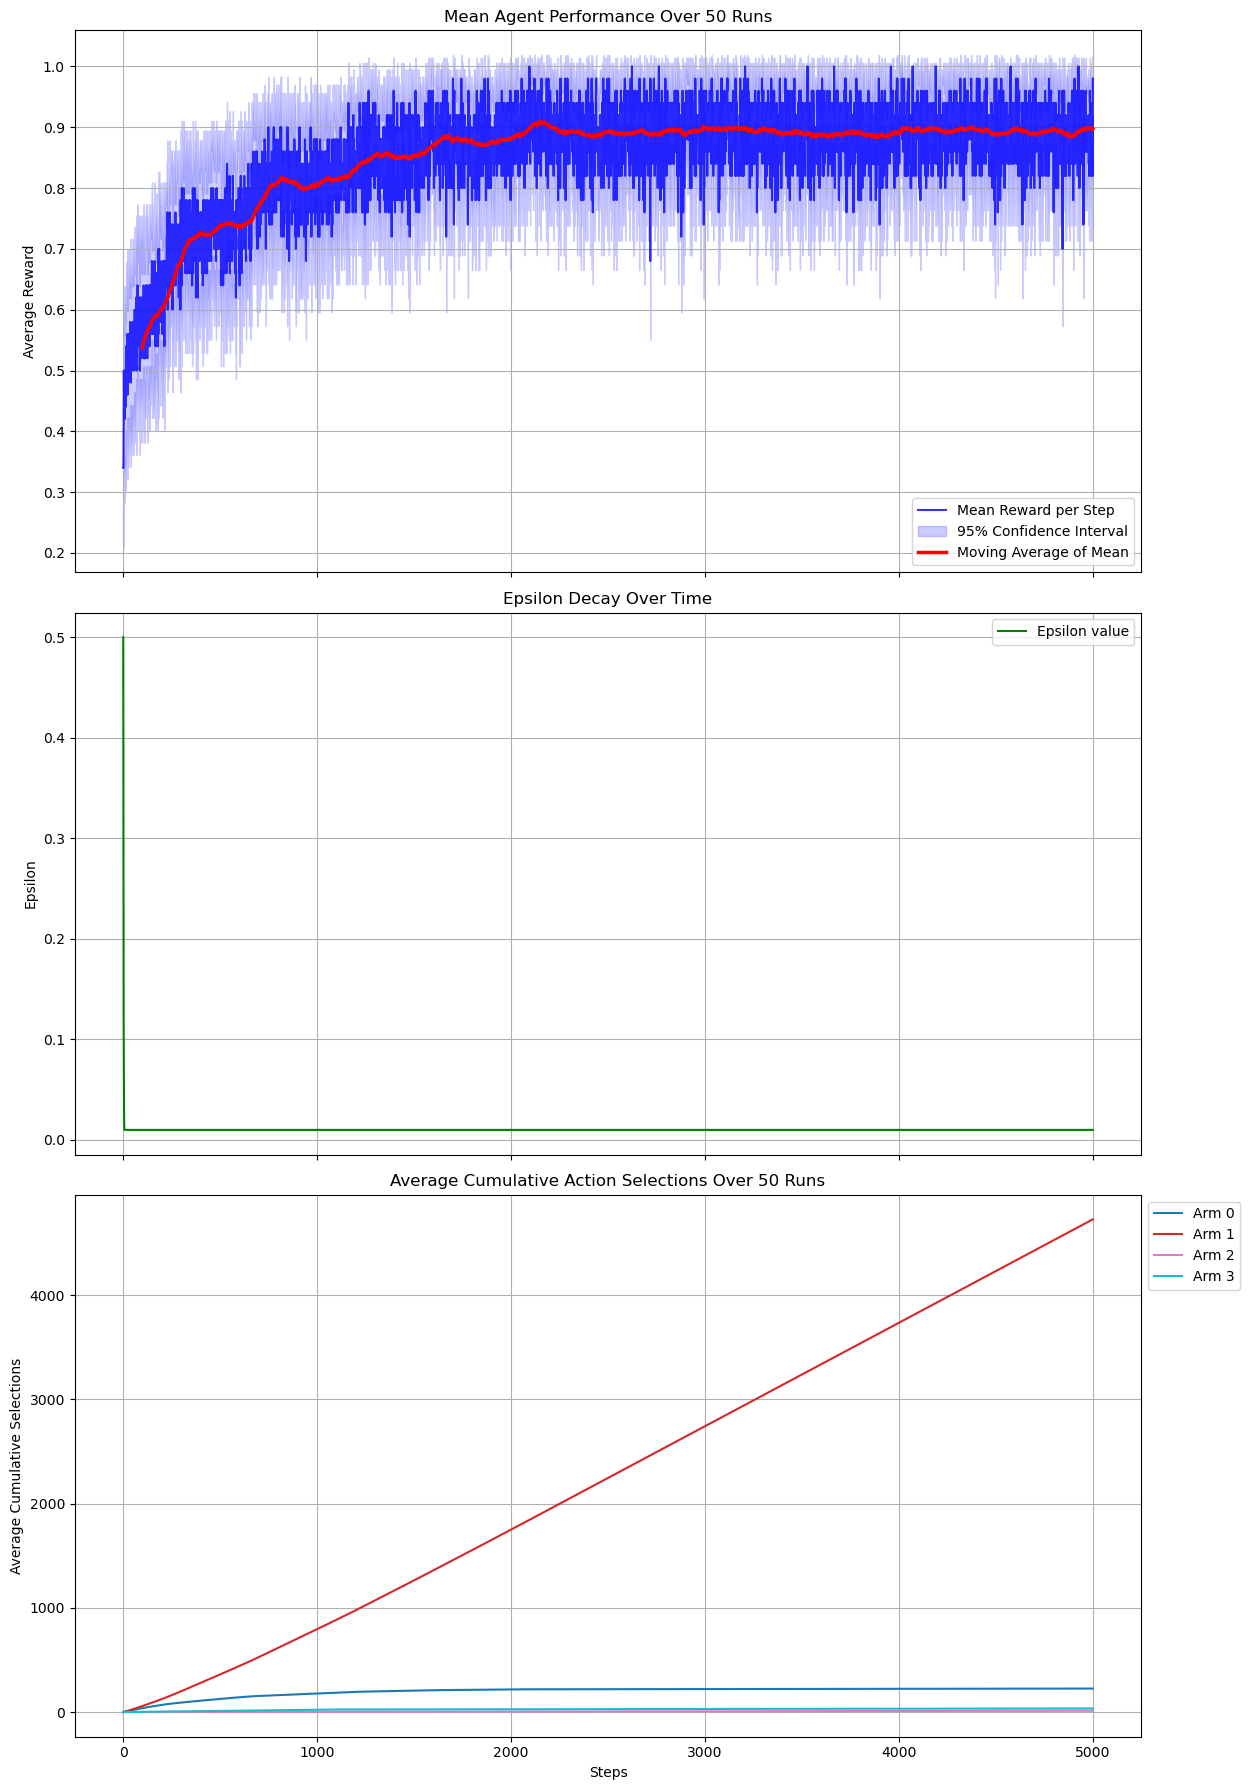

In [ ]:
logging.info("--- Simulation Start ---")

SIMULATION_STEPS = 5000
NUM_RUNS = 50
NUM_ARMS = 4

environment_parameters = {
    'num_arms': NUM_ARMS,
    'reward_model': 'bernoulli',
    'probs': np.array([0.01, 0.9, 0.02, 0.03])
}

# environment_parameters = {
#     'num_arms': NUM_ARMS,
#     'reward_model': 'normal',
#     'means': np.array([1, -1, 3, 2]),
#     'stds': np.ones(NUM_ARMS) * 0.5
# }

policy_parameters = {
    'initial_epsilon': 1.0,
    'decay_rate': 0.5,
    'min_epsilon': 0.01
}

logging.info(f"Environment Parameters: {environment_parameters}")
logging.info(f"Policy Parameters: {policy_parameters}")
logging.info(f"Run Parameters: SIMULATION_STEPS={SIMULATION_STEPS}, NUM_RUNS={NUM_RUNS}")

all_rewards_data, all_actions_data, final_epsilons_data = run_all_simulations(
    num_runs=NUM_RUNS,
    simulation_steps=SIMULATION_STEPS,
    policy_params=policy_parameters,
    env_params=environment_parameters
)

logging.info("--- Simulation Finish ---")

plot_results(
    all_rewards=all_rewards_data,
    all_actions=all_actions_data,
    epsilons=final_epsilons_data,
    num_runs=NUM_RUNS,
    num_arms=NUM_ARMS,
    simulation_steps=SIMULATION_STEPS
)

logging.info("--- Simulation Set Finished ---")